Laboratory Exercise 6

Nature-Inspired Computing And Optimization For Engineering Systems.

Reg-No: 23/EG/CO/027



In [1]:
# Load Project Dependencies
import ast
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from deap import base, creator, tools
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [2]:
# Load the Dataset
file_path = "../datasets/raw/borg_traces_data.csv"
data = pd.read_csv(file_path)
data.head()

,Unnamed: 0,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,...,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cpu_usage_distribution,tail_cpu_usage_distribution,cluster,event,failed
0,0,0,2,94591244395,3,1,200,0,144,168846390496,...,0.014435,0.000415,NaN,NaN,1.0,[0.00314331 0.00381088 0.00401306 0.00415039 0...,[0.00535583 0.00541687 0.00548553 0.00554657 0...,7,FAIL,1
1,1,2517305308183,2,260697606809,2,0,360,221495397286,335,85515092,...,0.000000,0.000000,NaN,NaN,1.0,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,7,FAIL,1
2,2,195684022913,6,276227177776,2,0,103,0,376,169321752432,...,0.010422,0.000235,0.939919,0.001318,1.0,[0.01344299 0.01809692 0.0201416 0.02246094 0...,[0.02902222 0.02929688 0.0295105 0.0296936 0...,7,SCHEDULE,0
3,3,0,2,10507389885,3,0,200,0,1977,178294817221,...,0.041626,0.000225,1.359102,0.007643,1.0,[0.03704834 0.04125977 0.04290771 0.04425049 0...,[0.05535889 0.05584717 0.05633545 0.05718994 0...,8,FAIL,1
4,4,1810627494172,3,25911621841,2,0,0,0,3907,231364893292,...,0.000272,0.000010,NaN,NaN,1.0,[0. 0. 0. 0. 0...,[0.00041485 0.00041485 0.00041485 0.00041485 0...,2,FINISH,0


In [3]:
# Examine the size, columns, and the data types.
print("Shape:", data.shape)
print("\nColumns:", list(data.columns))
print("\nData types:")
print(data.dtypes)


Shape: (405894, 34)

Columns: ['Unnamed: 0', 'time', 'instance_events_type', 'collection_id', 'scheduling_class', 'collection_type', 'priority', 'alloc_collection_id', 'instance_index', 'machine_id', 'resource_request', 'constraint', 'collections_events_type', 'user', 'collection_name', 'collection_logical_name', 'start_after_collection_ids', 'vertical_scaling', 'scheduler', 'start_time', 'end_time', 'average_usage', 'maximum_usage', 'random_sample_usage', 'assigned_memory', 'page_cache_memory', 'cycles_per_instruction', 'memory_accesses_per_instruction', 'sample_rate', 'cpu_usage_distribution', 'tail_cpu_usage_distribution', 'cluster', 'event', 'failed']

Data types:
Unnamed: 0                           int64
time                                 int64
instance_events_type                 int64
collection_id                        int64
scheduling_class                     int64
collection_type                      int64
priority                             int64
alloc_collection_id   

In [4]:
# Display the resource and scheduling columns as main references
data[['resource_request','start_time', 'end_time', 'priority',
'cluster']].head()

,resource_request,start_time,end_time,priority,cluster
0,"{'cpus': 0.020660400390625, 'memory': 0.014434...",274800000000,275100000000,200,7
1,"{'cpus': 0.00724029541015625, 'memory': 0.0013...",1800713000000,1800714000000,360,7
2,"{'cpus': 0.048583984375, 'memory': 0.004165649...",81300000000,81600000000,103,7
3,"{'cpus': 0.0704345703125, 'memory': 0.04162597...",1075500000000,1075800000000,200,8
4,"{'cpus': 0.00244903564453125, 'memory': 0.0002...",1565315000000,1565317000000,0,2


In [6]:
# Turn text based resource request to real numbers.
def parse_cpu_mem(series):
    cpu, mem = [], []
    for value in series:
        try:
            d = ast.literal_eval(value)
            cpu.append(float(d.get('cpus', 0)))
            mem.append(float(d.get('memory', 0)))
        except:
            cpu.append(0)
            mem.append(0)
    return np.array(cpu), np.array(mem)

# Call the helper function
req_cpu, req_mem = parse_cpu_mem(data['resource_request'])


In [7]:
# Display Task Duration 
duration = (data['end_time']- data['start_time']).clip(lower=0).to_numpy() / 1e6
print(duration)

[300.   1. 300. ... 300. 300. 300.]


In [8]:
# Display only valid tasks.
tasks = pd.DataFrame({'cpu': req_cpu, 'mem': req_mem, 'duration': duration})
tasks = tasks[(tasks['cpu'] > 0) & (tasks['duration'] > 0)].reset_index(drop=True)
print(tasks.head(10))
print(tasks.shape)


        cpu       mem  duration
0  0.020660  0.014435     300.0
1  0.007240  0.001303       1.0
2  0.048584  0.004166     300.0
3  0.070435  0.041626     300.0
4  0.002449  0.000232       2.0
5  0.061523  0.005409     161.0
6  0.005669  0.001562     300.0
7  0.022003  0.001501     300.0
8  0.008102  0.003613     300.0
9  0.097168  0.006767     300.0
(398833, 3)


In [9]:
# Pick a manageable subset
N_TASKS = 1000
tasks = tasks.head(N_TASKS).reset_index(drop=True)
print("Tasks kept:", len(tasks))
print(tasks.describe().round(4))

Tasks kept: 1000
             cpu        mem   duration
count  1000.0000  1000.0000  1000.0000
mean      0.0160     0.0082   210.5470
std       0.0309     0.0209   130.2539
min       0.0002     0.0000     1.0000
25%       0.0042     0.0013    27.7500
50%       0.0081     0.0030   300.0000
75%       0.0163     0.0065   300.0000
max       0.5830     0.2632   300.0000


In [10]:
# Define the optimization problem in plain terms
N_MACHINES = 5
cpu = tasks['cpu'].to_numpy()
mem = tasks['mem'].to_numpy()
dur = tasks['duration'].to_numpy()

In [11]:
# Give each machine a capacity
CPU_CAP = cpu.sum() / N_MACHINES * 1.5
MEM_CAP = mem.sum() / N_MACHINES * 1.5
print(f"Machines: {N_MACHINES}")
print(f"CPU cap each: {CPU_CAP:.3f}")
print(f"MEM cap each: {MEM_CAP:.3f}")

Machines: 5
CPU cap each: 4.813
MEM cap each: 2.451


In [12]:
# Compute key numbers
def schedule_metrics(assignment):
    assignment = np.asarray(assignment)
    load = np.zeros(N_MACHINES) # total run-time on each machine
    cpu_used = np.zeros(N_MACHINES)
    mem_used = np.zeros(N_MACHINES)

    for t in range(len(assignment)):
        m = assignment[t]
        load[m] += dur[t]
        cpu_used[m] += cpu[t]
        mem_used[m] += mem[t]

    makespan = load.max() # the busiest machine finishes last
    overload = (np.maximum(cpu_used - CPU_CAP, 0).sum() + 
                np.maximum(mem_used - MEM_CAP, 0).sum())

    return makespan, overload, cpu_used, mem_used

In [13]:
# 
if hasattr(creator, "FitnessMin"): del creator.FitnessMin
if hasattr(creator, "Individual"): del creator.Individual
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

In [14]:
# Define fitness function, and add penalty for when the capacity is exceeded.
def fitness(individual):
    makespan, overload, _, _ = schedule_metrics(individual)
    return (makespan + 1e6 * overload,)

In [15]:
# Register the GA building blocks
toolbox = base.Toolbox()
toolbox.register("gene", random.randint, 0, N_MACHINES - 1)# one task -> a machine
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.gene, N_TASKS)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", fitness)
toolbox.register("mate", tools.cxTwoPoint) # crossover
toolbox.register("mutate", tools.mutUniformInt, low=0, up=N_MACHINES - 1, indpb=0.1) # mutation
toolbox.register("select", tools.selTournament, tournsize=3) # selection

In [16]:
# Run the genetic Algorithm and record best fitness generation
POP_SIZE, N_GEN = 100, 50
CXPB, MUTPB = 0.7, 0.2
population = toolbox.population(n=POP_SIZE)

for individual in population:
    individual.fitness.values = toolbox.evaluate(individual)

hall_of_fame = tools.HallOfFame(1)
best_history = []
avg_history = []


for generation in range(N_GEN):
    # SELECTION
    offspring = toolbox.select(population, len(population))
    offspring = list(map(toolbox.clone, offspring))

# CROSSOVER
for child1, child2 in zip(offspring[::2], offspring[1::2]):
    if random.random() < CXPB:
        toolbox.mate(child1, child2)
        del child1.fitness.values
        del child2.fitness.values

# MUTATION
for individual in offspring:
    if random.random() < MUTPB:
        toolbox.mutate(individual)
        del individual.fitness.values

# EVALUATION
for individual in offspring:
    if not individual.fitness.valid:
        individual.fitness.values = toolbox.evaluate(individual)

population = offspring
hall_of_fame.update(population)
fitness_values = [ind.fitness.values[0] for ind in population]
best_history.append(min(fitness_values))
avg_history.append(np.mean(fitness_values))

best_schedule = hall_of_fame[0]
print(f"Best fitness found: {best_history[-1]:.2f}")


Best fitness found: 42845.00


In [17]:
# Compare the GA schedule against a random schedule
ga_makespan, ga_over, ga_cpu, ga_mem = schedule_metrics(best_schedule)

random_schedule = [random.randint(0, N_MACHINES - 1) for _ in
range(N_TASKS)]
rand_makespan, _, _, _ = schedule_metrics(random_schedule)

print(f"Random schedule makespan: {rand_makespan:.2f}")
print(f"GA schedule makespan : {ga_makespan:.2f}")

improvement = (rand_makespan - ga_makespan) / rand_makespan * 100
print(f"Improvement over random : {improvement:.1f}%")

Random schedule makespan: 46533.00
GA schedule makespan : 42845.00
Improvement over random : 7.9%


In [18]:
# Compute Utilization
cpu_util = ga_cpu / CPU_CAP
mem_util = ga_mem / MEM_CAP
print("CPU utilisation per machine:", np.round(cpu_util, 2))
print("Memory utilisation per machine:", np.round(mem_util, 2))
print(f"Average CPU utilisation: {cpu_util.mean():.2%}")
print(f"Average memory utilisation: {mem_util.mean():.2%}")

CPU utilisation per machine: [0.56 0.61 0.65 0.74 0.77]
Memory utilisation per machine: [0.51 0.64 0.56 0.74 0.88]
Average CPU utilisation: 66.67%
Average memory utilisation: 66.67%


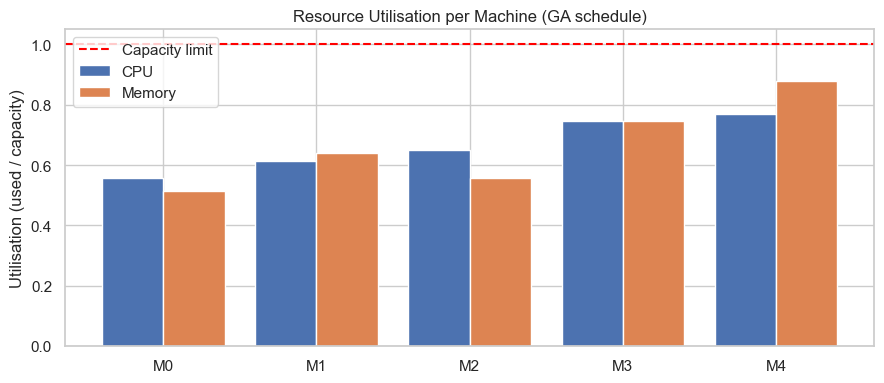

In [19]:
# Bar chart for GA Spread
machines = [f"M{j}" for j in range(N_MACHINES)]
x = np.arange(N_MACHINES)
plt.figure(figsize=(9, 4))
plt.bar(x - 0.2, cpu_util, width=0.4, label="CPU")
plt.bar(x + 0.2, mem_util, width=0.4, label="Memory")
plt.axhline(1.0, color='red', linestyle='--', label="Capacity limit")
plt.xticks(x, machines); plt.ylabel("Utilisation (used / capacity)")
plt.title("Resource Utilisation per Machine (GA schedule)")
plt.legend(); plt.tight_layout(); plt.show()

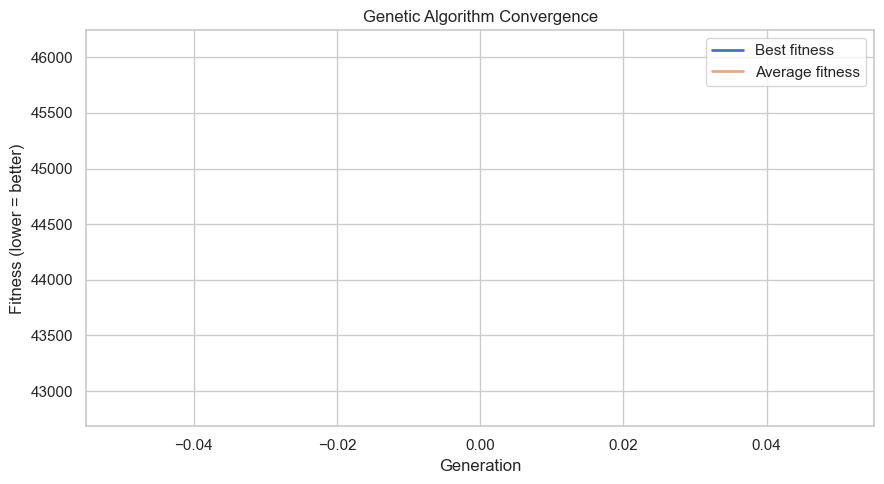

In [20]:
# Convergence curves
plt.figure(figsize=(9, 5))
plt.plot(best_history, label="Best fitness", linewidth=2)
plt.plot(avg_history, label="Average fitness", linewidth=2, alpha=0.7)
plt.xlabel("Generation"); plt.ylabel("Fitness (lower = better)")
plt.title("Genetic Algorithm Convergence")
plt.legend(); plt.tight_layout(); plt.show()
